Clínicas com volume antes e zeradas agora:
  • Cardiologia: último atendimento em 2026-01-20


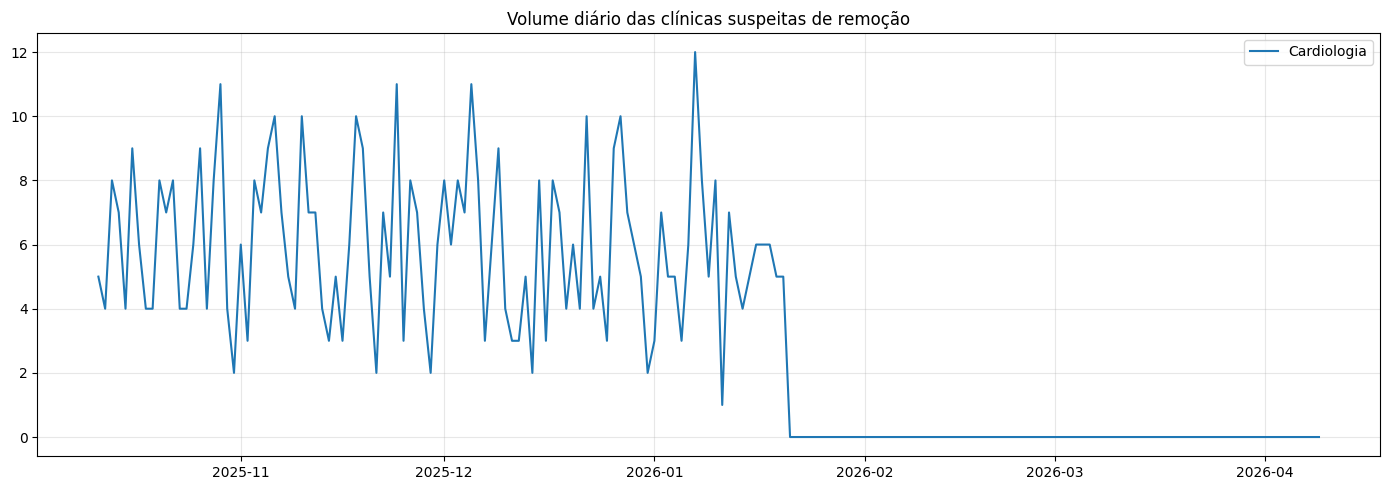

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet('../data/ml_ps_historico_chegadas.parquet')

# Volume diário por clínica nos últimos 180 dias
df['dt_dia'] = df['dt_entrada'].dt.date
recente = df[df['dt_entrada'] >= df['dt_entrada'].max() - pd.Timedelta(days=180)]
pivot = recente.groupby(['dt_dia', 'ds_clinica']).size().unstack(fill_value=0)

# Quais clínicas tinham volume antes e zeraram depois?
volume_inicio = pivot.iloc[:30].sum()   # 30 primeiros dias
volume_fim = pivot.iloc[-30:].sum()      # 30 últimos dias
candidatas = volume_inicio[(volume_inicio > 50) & (volume_fim == 0)].index.tolist()

print("Clínicas com volume antes e zeradas agora:")
for c in candidatas:
    serie = pivot[c]
    ultimo_atendimento = serie[serie > 0].index.max()
    print(f"  • {c}: último atendimento em {ultimo_atendimento}")

# Gráfico das candidatas
if candidatas:
    fig, ax = plt.subplots(figsize=(14, 5))
    for c in candidatas:
        ax.plot(pivot.index, pivot[c], label=c, linewidth=1.5)
    ax.set_title('Volume diário das clínicas suspeitas de remoção')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()